# CIFAR-10 Classification using PyTorch

In [20]:
# Import required libraries for building, training, and visualizing the neural network model.
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

In [21]:
# Load the CIFAR-10 training and test datasets.
transform = transforms.Compose([
    transforms.ToTensor()])
train_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform)
print(len(train_full))
print(len(test_dataset))

50000
10000


In [22]:
# Split the training dataset into training and validation sets, then check the size of each dataset.
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size])
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 40000
Validation: 10000
Test: 10000


In [23]:
# Create data loaders to load training, validation, and test data in batches for model training and evaluation.
batch_size = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)

In [24]:
# Define a feed-forward neural network with multiple fully connected layers for CIFAR-10 classification.
class FFNClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(3072, 1024),
            nn.ReLU(),


            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 10))

    def forward(self, x):
        return self.network(x)

In [25]:
# Create an instance of the FFN model and display its architecture.
model = FFNClassifier()

print(model)

FFNClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=1024, bias=True)
    (2): ReLU()
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [26]:
# Define the loss function and optimizer for training.
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001)


In [27]:
# Calculate the model accuracy on the dataset.
def calculate_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [28]:
# Train the model for 20 epochs and track accuracy on train, validation, and test sets.
epochs = 20

train_acc_list = []
val_acc_list = []
test_acc_list = []

for epoch in range(epochs):

    model.train()

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

    train_acc = calculate_accuracy(
        model,
        train_loader)

    val_acc = calculate_accuracy(
        model,
        val_loader)

    test_acc = calculate_accuracy(
        model,
        test_loader)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    test_acc_list.append(test_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}% | "
        f"Test: {test_acc:.2f}%")

Epoch 1/20 | Train: 35.30% | Val: 34.29% | Test: 34.82%
Epoch 2/20 | Train: 39.25% | Val: 37.99% | Test: 38.40%
Epoch 3/20 | Train: 42.82% | Val: 42.25% | Test: 42.66%
Epoch 4/20 | Train: 44.52% | Val: 42.55% | Test: 43.50%
Epoch 5/20 | Train: 47.12% | Val: 44.75% | Test: 46.27%
Epoch 6/20 | Train: 48.83% | Val: 45.34% | Test: 46.84%
Epoch 7/20 | Train: 48.14% | Val: 45.37% | Test: 46.08%
Epoch 8/20 | Train: 51.26% | Val: 47.09% | Test: 47.95%
Epoch 9/20 | Train: 52.56% | Val: 48.34% | Test: 49.15%
Epoch 10/20 | Train: 54.02% | Val: 48.20% | Test: 49.91%
Epoch 11/20 | Train: 54.48% | Val: 48.61% | Test: 49.78%
Epoch 12/20 | Train: 56.16% | Val: 49.41% | Test: 50.80%
Epoch 13/20 | Train: 56.32% | Val: 48.62% | Test: 49.93%
Epoch 14/20 | Train: 56.67% | Val: 48.74% | Test: 50.17%
Epoch 15/20 | Train: 58.06% | Val: 49.82% | Test: 50.85%
Epoch 16/20 | Train: 59.75% | Val: 50.75% | Test: 51.55%
Epoch 17/20 | Train: 61.37% | Val: 50.93% | Test: 51.24%
Epoch 18/20 | Train: 61.78% | Val: 50.66

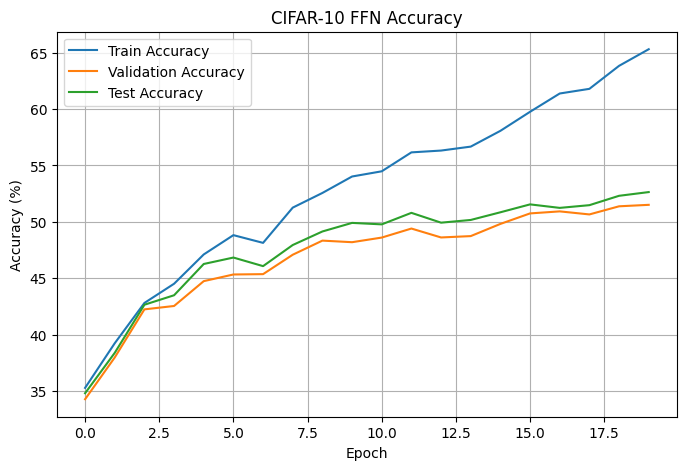

In [29]:
# Plot training, validation, and test accuracy over epochs.
plt.figure(figsize=(8,5))

plt.plot(
    train_acc_list,
    label="Train Accuracy")

plt.plot(
    val_acc_list,
    label="Validation Accuracy")

plt.plot(
    test_acc_list,
    label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "CIFAR-10 FFN Accuracy")

plt.legend()

plt.grid()

plt.show()

In [30]:
# Define CIFAR-10 class labels and select a sample image from the test dataset.
classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck']
image, label = test_dataset[0]

In [31]:
# Predict the class of a test image and compare it with the actual label.
model.eval()

with torch.no_grad():

    output = model(
        image.unsqueeze(0))

    prediction = torch.argmax(output)

predicted_class = classes[
    prediction.item()]

actual_class = classes[label]

print("Actual:", actual_class)
print("Predicted:", predicted_class)

Actual: cat
Predicted: ship


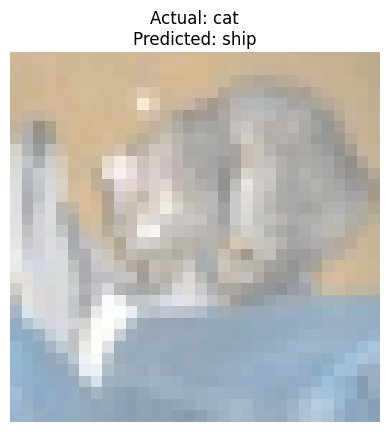

In [32]:
# Display the test image with its actual and predicted labels.
img = image / 2 + 0.5

plt.imshow(
    img.permute(1,2,0))

plt.title(
    f"Actual: {actual_class}\nPredicted: {predicted_class}")

plt.axis("off")

plt.show()